# Machine Learning-Based Algorithm Selection for 0-1 Knapsack Optimization

This notebook investigates whether machine learning models can predict suitable optimization algorithms based on problem characteristics.

The task is formulated as a binary classification problem:

Input:
- problem instance features

Output:
- selected algorithm:
  - Greedy
  - Dynamic Programming

## 1. Dataset Preparation

In [75]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../results/algorithm_selection_dataset.csv"
)

df.head()

,n_items,capacity_ratio,mean_weight,std_weight,mean_profit,std_profit,mean_ratio,std_ratio,correlation,best_algorithm
0,100,0.246604,47.850,26.880244,105.210,54.008758,2.631882,1.573177,strong,dp
1,100,0.898862,45.680,29.341057,51.900,30.421867,3.188816,7.267174,uncorrelated,greedy
2,200,0.322635,53.125,27.297607,49.375,29.811313,2.296672,7.780452,uncorrelated,greedy
3,50,0.369032,44.820,28.921750,66.140,27.891224,8.477020,21.327419,inverse,greedy
4,100,0.153505,51.790,25.747736,58.260,26.831183,4.381772,12.084882,inverse,greedy


In [76]:
df.shape

(500, 10)

## 2. Algorithm Selection Distribution

In [77]:
df["best_algorithm"].value_counts()

best_algorithm
greedy    331
dp        169
Name: count, dtype: int64

## 3. Feature Descrption

The extracted features characterize different aspects of optimization instances.

These features are designed to capture the structural characteristics that influence the performance of different optimization algorithms.

The features include:

- n_items:
    Number of items in the knapsack instance.

- capacity_ratio:
    Ratio between knapsack capacity and total item weights.

- mean_weight / std_weight:
    Statistical properties of item weights.

- mean_profit / std_profit:
    Statistical properties of item profits.

- mean_ratio / std_ratio:
    Distribution characteristics of profit-to-weight ratios.

- correlation:
    Weight-profit relationship structure.

## 4. Target Definition

The target variable represents the preferred algorithm under a runtime-quality trade-off.

Instead of selecting the algorithm purely based on solution quality, a cost-aware objective is introduced:

$$
Score = Profit - \lambda \times Runtime
$$

where λ controls the trade-off between solution quality and computational efficiency.

In this experiment, λ is set to 100.

A smaller λ places more emphasis on solution quality, while a larger λ increases the penalty on computational cost.

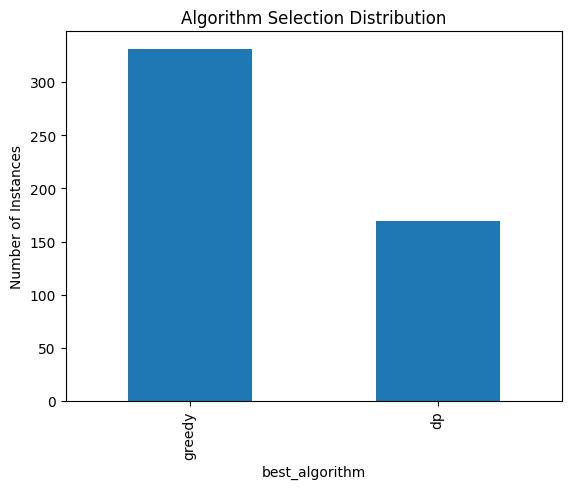

In [78]:
import matplotlib.pyplot as plt

df["best_algorithm"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Algorithm Selection Distribution"
)

plt.ylabel(
    "Number of Instances"
)

plt.show()

## 5. Data Preprocessing

The dataset contains both numerical and categorical features.

A preprocessing pipeline is used to ensure consistent transformation during training and evaluation.

Numerical features:
- Standardization

Categorical features:
- One-hot encoding

In [79]:
from sklearn.model_selection import train_test_split


X = df.drop(
    "best_algorithm",
    axis=1
)

y = df["best_algorithm"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_features = [
    "n_items",
    "capacity_ratio",
    "mean_weight",
    "std_weight",
    "mean_profit",
    "std_profit",
    "mean_ratio",
    "std_ratio"
]


categorical_features = [
    "correlation"
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [81]:
X_train.shape

(400, 9)

In [82]:
y_train.value_counts()

best_algorithm
greedy    265
dp        135
Name: count, dtype: int64

## 6. Baseline Models

To evaluate whether problem characteristics can predict suitable optimization algorithms, baseline classification models are trained.

The first baseline model is Logistic Regression, which provides a simple linear classification benchmark.

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [84]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [85]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['n_items', 'capacity_ratio',
                                                   'mean_weight', 'std_weight',
                                                   'mean_profit', 'std_profit',
                                                   'mean_ratio', 'std_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['correlation'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [86]:
y_pred = logistic_model.predict(
    X_test
)

In [87]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [88]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

Accuracy: 0.78


In [89]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

          dp       0.70      0.62      0.66        34
      greedy       0.81      0.86      0.84        66

    accuracy                           0.78       100
   macro avg       0.76      0.74      0.75       100
weighted avg       0.78      0.78      0.78       100



In [90]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[21 13]
 [ 9 57]]


## 7. Random Forest Model

Random Forest is introduced to capture potential nonlinear relationships between problem characteristics and algorithm performance.

Compared with Logistic Regression, tree-based models can naturally model conditional decision boundaries.

In [91]:
from sklearn.ensemble import RandomForestClassifier

In [92]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [93]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['n_items', 'capacity_ratio',
                                                   'mean_weight', 'std_weight',
                                                   'mean_profit', 'std_profit',
                                                   'mean_ratio', 'std_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['correlation'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [94]:
rf_pred = rf_model.predict(
    X_test
)

In [95]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

Accuracy: 0.77
              precision    recall  f1-score   support

          dp       0.70      0.56      0.62        34
      greedy       0.79      0.88      0.83        66

    accuracy                           0.77       100
   macro avg       0.75      0.72      0.73       100
weighted avg       0.76      0.77      0.76       100

[[19 15]
 [ 8 58]]


## 8. Feature Importance Analysis

Random Forest allows interpretation of feature contributions.
Feature importance is analysed to identify which problem characteristics influence algorithm selection.

In [96]:
rf = rf_model.named_steps["classifier"]

importances = rf.feature_importances_

In [97]:
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances
    }
)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
0,num__n_items,0.166297
5,num__std_profit,0.131563
4,num__mean_profit,0.129041
7,num__std_ratio,0.111143
1,num__capacity_ratio,0.107935
6,num__mean_ratio,0.107184
3,num__std_weight,0.103883
2,num__mean_weight,0.084086
9,cat__correlation_strong,0.026129
8,cat__correlation_inverse,0.013118


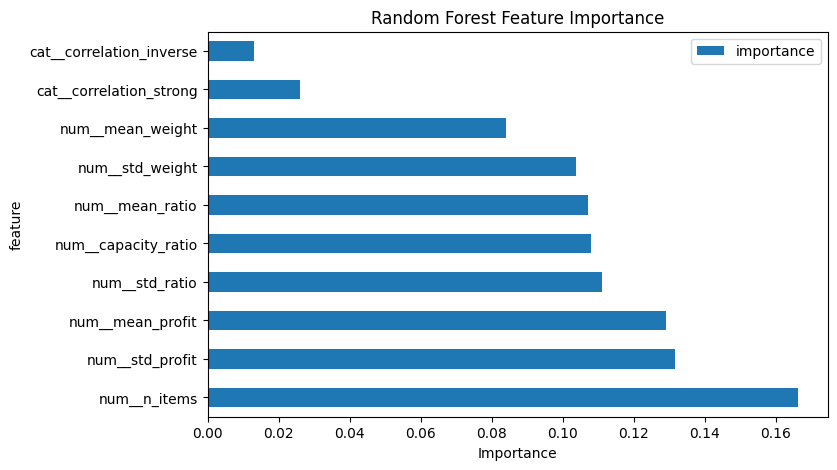

In [98]:
importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,5)
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.show()

## 9. XGBoost Model

XGBoost is introduced as an advanced gradient boosting model.

Compared with individual decision trees or random forests, gradient boosting sequentially improves weak learners by minimizing prediction errors.

This model is expected to capture complex nonlinear relationships between problem characteristics and algorithm selection.

In [99]:
from xgboost import XGBClassifier

In [100]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print(
    "Encoded classes:", encoder.classes_
)

Encoded classes: ['dp' 'greedy']


In [101]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

Parameters:

- n_estimators:
  Number of boosting rounds.

- learning_rate:
  Controls contribution of each tree.

- max_depth:
  Controls tree complexity.

In [102]:
xgb_model.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['n_items', 'capacity_ratio',
                                                   'mean_weight', 'std_weight',
                                                   'mean_profit', 'std_profit',
                                                   'mean_ratio', 'std_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['correlation'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylev...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [103]:
xgb_pred_encoded = xgb_model.predict(
    X_test
)

xgb_pred = encoder.inverse_transform(
    xgb_pred_encoded
)

In [104]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_pred
    )
)


print(
    classification_report(
        y_test,
        xgb_pred
    )
)


print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

Accuracy: 0.78
              precision    recall  f1-score   support

          dp       0.70      0.62      0.66        34
      greedy       0.81      0.86      0.84        66

    accuracy                           0.78       100
   macro avg       0.76      0.74      0.75       100
weighted avg       0.78      0.78      0.78       100

[[21 13]
 [ 9 57]]
